In [64]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [65]:
# data visualisation and manipulation
import numpy as np, pandas as pd, re, matplotlib.pyplot as plt, seaborn as sns, math, random

from matplotlib import style
from collections import Counter

#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score,precision_score, recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.svm import SVC
#preprocess.
from keras.preprocessing.image import ImageDataGenerator

#dl libraraies
import tensorflow as tf
from tensorflow.keras import layers
from keras import backend as K
from keras.models import Sequential, load_model, Model
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical
from vit_keras import vit
import tensorflow_addons as tfa

# specifically for cnn
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization


import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
from tqdm import tqdm
import os
import glob
import tempfile
from PIL import Image

In [66]:
class CONFIG:
    HEIGHT = 224
    WIDTH = 224
    SEED = 42
    FOLDS = 5
    IMAGE_SIZES = [224, 224, 224, 224, 224] #same img size for each fold
    BATCH_SIZE = [16] * FOLDS
    EPOCHS = [15] * FOLDS
    WEIGHTS = [1/FOLDS] * FOLDS
    AUTO = tf.data.experimental.AUTOTUNE
    VERBOSE = 1

In [67]:
ROTATION = 180.0
SHEAR = 2.0
H_ZOOM = 8.0
W_ZOOM = 8.0
H_SHIFT = 8.0
W_SHIFT = 8.0

def get_matrix(rotation, shear, height_zoom, width_zoom, height_shift, width_shift):
    rotation = math.pi * rotation / 180.
    shear = math.pi * shear / 180.
    def get_3x3_matrix(lst):
        return tf.reshape(tf.concat([lst], axis = 0), [3,3])
    #rotation
    c1 = tf.math.cos(rotation)
    s1 = tf.math.sin(rotation)
    one = tf.constant([1], dtype='float32')
    zero = tf.constant([0], dtype='float32')

    rotation_matrix = get_3x3_matrix([c1, s1, zero,
                                   -s1, c1, zero,
                                   zero, zero, one
                                ])
    # Shear matrix
    c2 = tf.math.cos(shear)
    s2 = tf.math.sin(shear)

    shear_matrix = get_3x3_matrix([one, s2, zero,
                                zero, c2, zero,
                                zero, zero, one])

    #Zoom mat
    zoom_matrix = get_3x3_matrix([one/height_zoom, zero, zero,
                               zero, one/width_zoom, zero,
                               zero, zero, one])
    # Shift mat
    shift_matrix = get_3x3_matrix([one, zero, height_shift,
                               zero, one, width_shift,
                               zero, zero, one])
    return K.dot(K.dot(rotation_matrix, shear_matrix), K.dot(zoom_matrix, shift_matrix))

def apply_random_transformations(image, DIM=224):
    XDIM = DIM%2

    rot = ROTATION * tf.random.normal([1], dtype='float32')
    shr = SHEAR * tf.random.normal([1], dtype='float32')
    h_zoom = 1.0 + tf.random.normal([1], dtype='float32') / H_ZOOM
    w_zoom = 1.0 + tf.random.normal([1], dtype='float32') / W_ZOOM
    h_shift = H_SHIFT * tf.random.normal([1], dtype='float32')
    w_shift = W_SHIFT * tf.random.normal([1], dtype='float32')

    # get tranformation matrix
    m = get_matrix(rot, shr, h_zoom, w_zoom, h_shift, w_shift)
    #List Destination Pixel Indices
    x = tf.repeat(tf.range(DIM//2, -DIM//2, -1), DIM)
    y = tf.tile(tf.range(-DIM//2, DIM//2), [DIM])
    z = tf.ones([DIM*DIM], dtype='int32')
    idx = tf.stack([x, y, z])

    #Rotate Destination Pixels Onto Origin Pixels
    idx2 = K.dot(m, tf.cast(idx, dtype='float32'))
    idx2 = K.cast(idx2, dtype='int32')
    idx2 = K.clip(idx2, -DIM//2+XDIM+1, DIM//2)

    #find origin Pixel Values
    idx3 = tf.stack([DIM//2-idx2[0,], DIM//2-1+idx2[1,]])
    d = tf.gather_nd(image, tf.transpose(idx3))

    return tf.reshape(d, [DIM, DIM, 3])


In [68]:
def read_labeled_tfrecord(example):
    """ parse a TFRecord example into an image and label. """
    tfrec_format = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.float32)
    }
    example = tf.io.parse_single_example(example, tfrec_format)
    image = tf.io.decode_jpeg(example['image'], channels = 3)

    # Normalize the image to [0, 1] range
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Get the label
    label = example['label']

    return image, label

def prepare_image(img, augment = True, dim = 224):
    """ Prepare an image for training or evaluation, with optional augmentation. """
    if augment:
        img = apply_random_transformations(img, DIM = dim)
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_saturation(img, 0.7, 1.3)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_brightness(img, 0.1)

    # Resize the image if necessary
    img = tf.image.resize(img, [dim, dim])

    return img

def count_data_items(file_paths):
    """ Count the total number of items in a list of TFRecord files. """
    total_items = 0
    for file_path in file_paths:
        for record in tf.data.TFRecordDataset(file_path):
            total_items +=1

    return total_items


In [69]:
def get_dataset(files, augment = False, shuffle = False, repeat = False, dim = 224):
    """ Create a TensorFlow dataset from TFRecord files.
    Parameters:
    -files: List of TFRecord files.
    -augment: Boolean, whether to apply data augmentation.
    -shuffle: Boolean, whether to shuffle the dataset.
    -repeat: Boolean, whether to repeat the dataset.
    -labeled: Boolean, whether the TFRecords contain labels.
    Returns:
    - A TensorFlow dataset ready for training or evaluation.
    """
    ds = tf.data.TFRecordDataset(files, num_parallel_reads = tf.data.experimental.AUTOTUNE)
    ds = ds.cache()

    if repeat:
        ds = ds.repeat()
    if shuffle:
        ds = ds.shuffle(1024 * 8)
        opt = tf.data.Options()
        opt.experimental_deterministic = False
        ds = ds.with_options(opt)
    ds = ds.map(read_labeled_tfrecord, num_parallel_calls = tf.data.experimental.AUTOTUNE)
    ds = ds.map(lambda img, label: (prepare_image(img, augment = augment, dim = dim), label), num_parallel_calls = tf.data.experimental.AUTOTUNE)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE)

    # Convert datasets to arrays for compatibility with Stratified Kfold
    images = []
    labels = []
    for features, label in ds:
        images.append(features.numpy())
        labels.append(label.numpy())
    return np.array(images), np.array(labels)


In [70]:
METRICS = [
    tf.keras.metrics.BinaryCrossentropy(name = 'Cross Entropy'),
    tf.keras.metrics.F1Score(name = 'f1_score'),
    tf.keras.metrics.TruePositives(name = 'TP'),
    tf.keras.metrics.FalsePositives(name = 'FP'),
    tf.keras.metrics.TrueNegatives(name = 'TN'),
    tf.keras.metrics.FalseNegatives(name = 'FN'),
    tf.keras.metrics.BinaryAccuracy(name = 'accuracy'),
    tf.keras.metrics.BinaryAccuracy(name='val_auc'),
    tf.keras.metrics.Precision(name = 'precision'),
    tf.keras.metrics.Recall(name = 'recall'),
    tf.keras.metrics.AUC(name = 'auc'),
    tf.keras.metrics.AUC(name = 'prc', curve = 'PR'), #precision recall curve
]

In [41]:
input_shape = (CONFIG.HEIGHT, CONFIG.WIDTH, 3)
inputs = tf.keras.layers.Input(shape=input_shape)
base_efn = tf.keras.applications.EfficientNetV2B1(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs,
    pooling=None,
    classes=2,
    classifier_activation='sigmoid',
    include_preprocessing=False
)

In [131]:
feature_extractor = Model(inputs = base_efn.input, outputs = base_efn.output) 
def extract_features(images, model):
    features = model.predict(images)
    flattened_features = features.reshape(features.shape[0], -1)
    return flattened_features

In [71]:
tfrec_train_files = tf.io.gfile.glob('../../../dataset/task1/tf_records/train00.tfrec')
tfrec_val_files = tf.io.gfile.glob('../../../dataset/task1/tf_records/val00.tfrec')
tfrec_test_files = tf.io.gfile.glob('../../../dataset/task1/tf_records/test00.tfrec')

#Load datasets
train_data, train_labels = get_dataset(tfrec_train_files, augment = True, shuffle = True, repeat = False, dim = 224)
val_data, val_labels =  get_dataset(tfrec_val_files, augment = True, shuffle = True, repeat = False, dim = 224)
test_data, test_labels = get_dataset(tfrec_test_files, augment = False, shuffle = False, repeat = False, dim = 224)

In [133]:
train_features = extract_features(train_data, feature_extractor) 
val_features = extract_features(val_data, feature_extractor) 
test_features = extract_features(test_data, feature_extractor)

19/19 [==============================] - 18s 957ms/step


In [134]:
svm_classifier = SVC(kernel = 'linear', C = 1.0)
svm_classifier.fit(train_features, train_labels) 
y_pred = svm_classifier.predict(val_features) 

#Evaluate 
print("Accuracy:", accuracy_score(val_labels, y_pred))
print("Classification Report: \n", classification_report(val_labels, y_pred)) 

Accuracy: 0.7266666666666667
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.80      0.88      0.84       120
         1.0       0.21      0.13      0.16        30

    accuracy                           0.73       150
   macro avg       0.51      0.50      0.50       150
weighted avg       0.68      0.73      0.70       150



## TEST 

In [135]:
#Test Data 
y_pred = svm_classifier.predict(test_features) 

#Evaluate 
print("Accuracy:", accuracy_score(test_labels, y_pred)) 
print("Classification Report: \n", classification_report(test_labels, y_pred)) 

Accuracy: 0.765
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.81      0.93      0.86       483
         1.0       0.24      0.09      0.13       117

    accuracy                           0.77       600
   macro avg       0.52      0.51      0.50       600
weighted avg       0.70      0.77      0.72       600



In [72]:
def test_evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    # Convert predictions to binary (0, 1)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Classification Report
    report = classification_report(y_test, predicted_labels, target_names = ['Class 0', 'Class 1'], output_dict = True)

    # ROC AUC Score
    roc = roc_auc_score(y_test, predictions)
    print(f'ROC AUC Score: {roc}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, predicted_labels)
    TN, FP, FN, TP = cm.ravel()
    sp = TN / (TN + FP)
    # Plot CM
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Class 0', 'Class 1'])
    disp.plot()
    plt.show()

    # Metrics
    class_nevus_keratosis = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_melanoma = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})

    # Extract Metrics
    metrics_data = {
        'Metric': ['Precision', 'Recall/Sensitivity', 'F1-Score', 'Support'],
        'Class 0': [class_nevus_keratosis['precision'], class_nevus_keratosis['recall'], class_nevus_keratosis['f1-score'], class_nevus_keratosis['support']],
        'Class 1': [class_melanoma['precision'], class_melanoma['recall'], class_melanoma['f1-score'], class_melanoma['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'Specificity': [sp, '', '', ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(metrics_data)

    # DataFrame for CM
    #df_conf_matrix = pd.DataFrame(cm, index = ['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'Predicted 1'])

    #Display tables
    print("Classification Metrics:")
    print(df_metrics.to_string(index = False))
    #print("\n Confusion Matrix:")
    #print(df_conf_matrix.to_string(index = True))


ROC AUC Score: 0.510776662950576


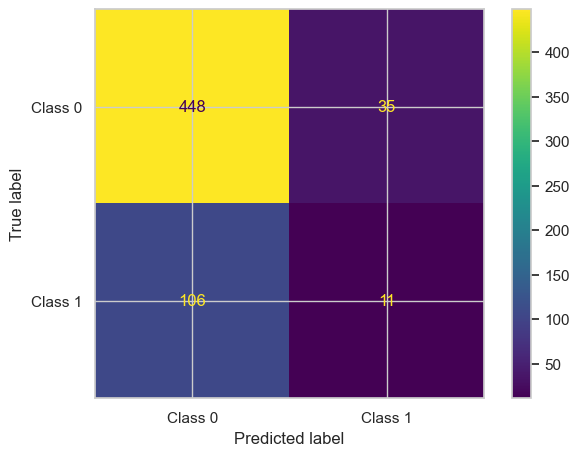

Classification Metrics:
            Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.808664   0.239130    0.765  0.523897     0.697605    0.927536      0.510777
Recall/Sensitivity   0.927536   0.094017           0.510777        0.765                          
          F1-Score   0.864031   0.134969             0.4995     0.721864                          
           Support 483.000000 117.000000                                                          


In [137]:
#Morphological (256, 256) 
test_evaluate(svm_classifier, test_features, test_labels) 

ROC AUC Score: 0.5838509316770186


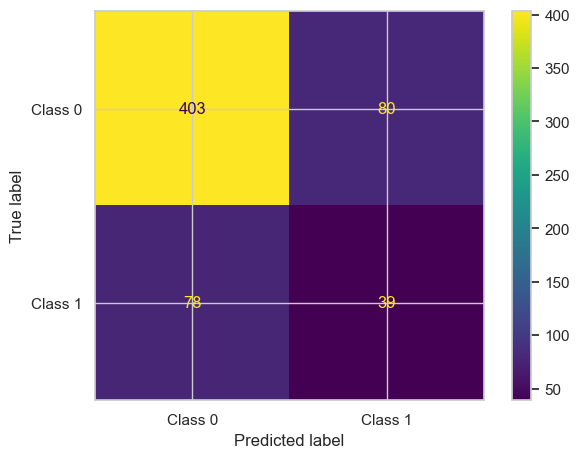

Classification Metrics:
            Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.837838   0.327731  0.736667  0.582784     0.738367    0.834369      0.583851
Recall/Sensitivity   0.834369   0.333333            0.583851     0.736667                          
          F1-Score   0.836100   0.330508            0.583304     0.737509                          
           Support 483.000000 117.000000                                                           


In [49]:
#Morphological (256, 256) 
test_evaluate(svm_classifier, test_features, test_labels)

ROC AUC Score: 0.5378510378510379


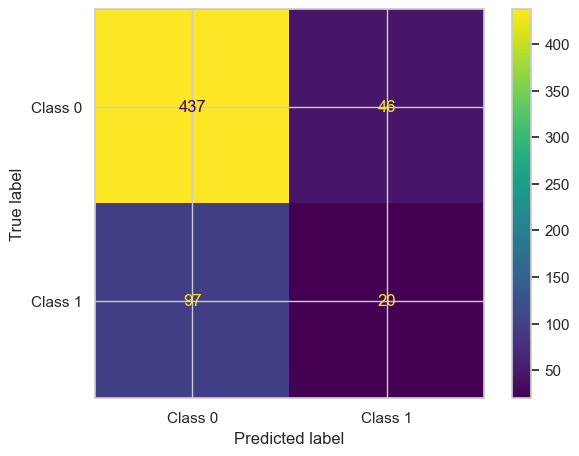

Classification Metrics:
            Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.818352   0.303030  0.761667  0.560691     0.717864    0.904762      0.537851
Recall/Sensitivity   0.904762   0.170940            0.537851     0.761667                          
          F1-Score   0.859390   0.218579            0.538985     0.734432                          
           Support 483.000000 117.000000                                                           


In [34]:
#Morphological (224, 224)
test_evaluate(svm_classifier, test_features, test_labels)

ROC AUC Score: 0.5199607156128895


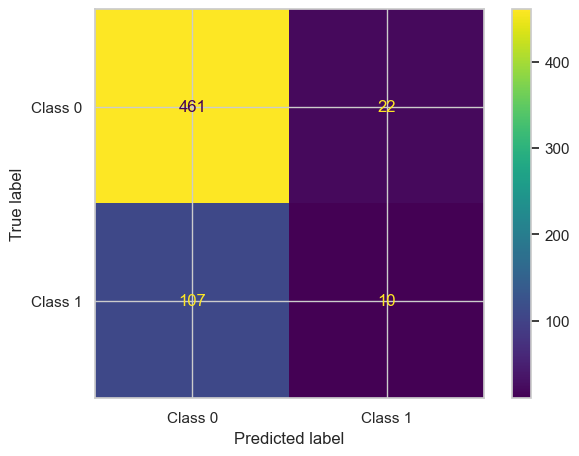

Classification Metrics:
            Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.811620   0.312500    0.785   0.56206     0.714291    0.954451      0.519961
Recall/Sensitivity   0.954451   0.085470           0.519961        0.785                          
          F1-Score   0.877260   0.134228           0.505744     0.732369                          
           Support 483.000000 117.000000                                                          


In [19]:
#EFN+SVM
test_evaluate(svm_classifier, test_features, test_labels)

## Fine-Tunning

In [94]:
input_shape = (CONFIG.HEIGHT, CONFIG.WIDTH, 3)
inputs = tf.keras.layers.Input(shape=input_shape)
base_efn = tf.keras.applications.EfficientNetV2B1(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs,
    pooling=None,
    classes=2,
    classifier_activation='sigmoid',
    include_preprocessing=False
)

In [95]:
for layer in base_efn.layers:
    if layer.name.startswith('block1') or layer.name.startswith('block2'):
        layer.trainable = False

In [96]:
feature_extractor = Model(inputs = base_efn.input, outputs = base_efn.output) 
def extract_features(images, model):
    features = model.predict(images)
    flattened_features = features.reshape(features.shape[0], -1)
    return flattened_features

In [97]:
train_features = extract_features(train_data, feature_extractor) 
val_features = extract_features(val_data, feature_extractor) 
test_features = extract_features(test_data, feature_extractor) 

19/19 [==============================] - 38s 2s/step


In [98]:
svm_classifier = SVC(kernel = 'linear', C = 1.0) 
svm_classifier.fit(train_features, train_labels) 
y_pred = svm_classifier.predict(val_features) 

#Evaluate 
print("Accuracy:", accuracy_score(val_labels, y_pred)) 
print("Classification Report: \n", classification_report(val_labels, y_pred)) 

Accuracy: 0.7533333333333333
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.82      0.89      0.85       120
         1.0       0.32      0.20      0.24        30

    accuracy                           0.75       150
   macro avg       0.57      0.55      0.55       150
weighted avg       0.72      0.75      0.73       150



In [92]:
#Test Data 
y_pred = svm_classifier.predict(test_features) 

#Evaluate 
print("Accuracy:", accuracy_score(test_labels, y_pred)) 
print("Classification Report: \n", classification_report(test_labels, y_pred)) 

Accuracy: 0.7416666666666667
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       483
         1.0       0.34      0.34      0.34       117

    accuracy                           0.74       600
   macro avg       0.59      0.59      0.59       600
weighted avg       0.74      0.74      0.74       600



### Unfreez block 1-5

ROC AUC Score: 0.5407177363699104


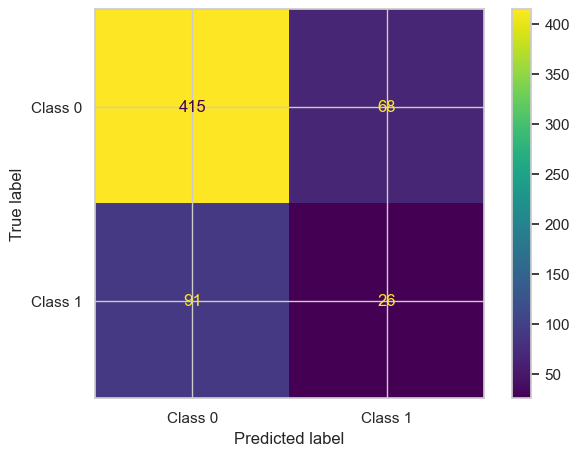

Classification Metrics:
            Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.820158   0.276596    0.735  0.548377     0.714163    0.859213      0.540718
Recall/Sensitivity   0.859213   0.222222           0.540718        0.735                          
          F1-Score   0.839232   0.246445           0.542839     0.723638                          
           Support 483.000000 117.000000                                                          


In [47]:
test_evaluate(svm_classifier, test_features, test_labels) 

### Unfreez block 1-4

ROC AUC Score: 0.5901948293252642


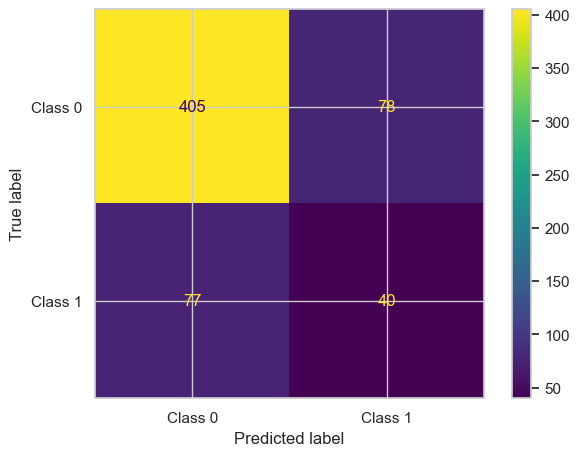

Classification Metrics:
            Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.840249   0.338983  0.741667  0.589616     0.742502    0.838509      0.590195
Recall/Sensitivity   0.838509   0.341880            0.590195     0.741667                          
          F1-Score   0.839378   0.340426            0.589902     0.742082                          
           Support 483.000000 117.000000                                                           


In [86]:
test_evaluate(svm_classifier, test_features, test_labels) 

### Unfreez block 1-3

ROC AUC Score: 0.5901948293252642


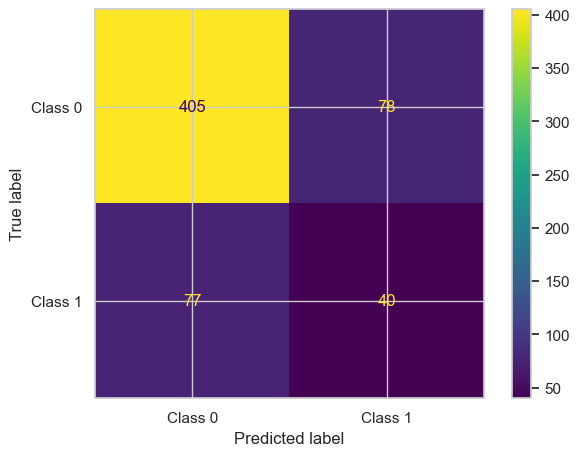

Classification Metrics:
            Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.840249   0.338983  0.741667  0.589616     0.742502    0.838509      0.590195
Recall/Sensitivity   0.838509   0.341880            0.590195     0.741667                          
          F1-Score   0.839378   0.340426            0.589902     0.742082                          
           Support 483.000000 117.000000                                                           


In [93]:
test_evaluate(svm_classifier, test_features, test_labels) 

### Unfreez block 1-2

ROC AUC Score: 0.5901948293252642


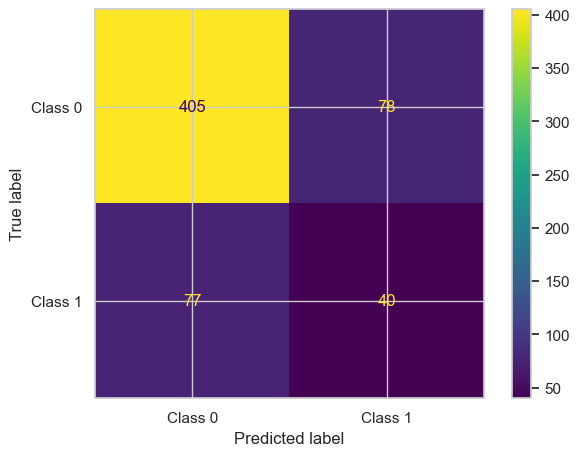

Classification Metrics:
            Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg Specificity ROC-AUC-Score
         Precision   0.840249   0.338983  0.741667  0.589616     0.742502    0.838509      0.590195
Recall/Sensitivity   0.838509   0.341880            0.590195     0.741667                          
          F1-Score   0.839378   0.340426            0.589902     0.742082                          
           Support 483.000000 117.000000                                                           


In [99]:
test_evaluate(svm_classifier, test_features, test_labels) 